# Erstellung der Occupancy map
Ziel dieses Notebooks ist es, die vorliegenden PDF Plände in eine nutzbare Occupancy Map umzuwandeln. <br>
Die vorliegenden Pläne enthalten je zwei Stockwerke. Sie sind zunächst zu teilen. Anschließend sind Bemaßungen und Beschriftungen zu entfernen.<br>
Die resultierende Karte muss in eine binäre Grid-Map umgewandelt werden. Diese kann anschließend im Particle Filter verwendet werden.

## Import und Definition

In [100]:
import numpy as np

import matplotlib.pyplot as plt
import cv2

RESOLUTION = 0.2 # Size of each pixel in m

## EG
### Grundrissplan einlesen

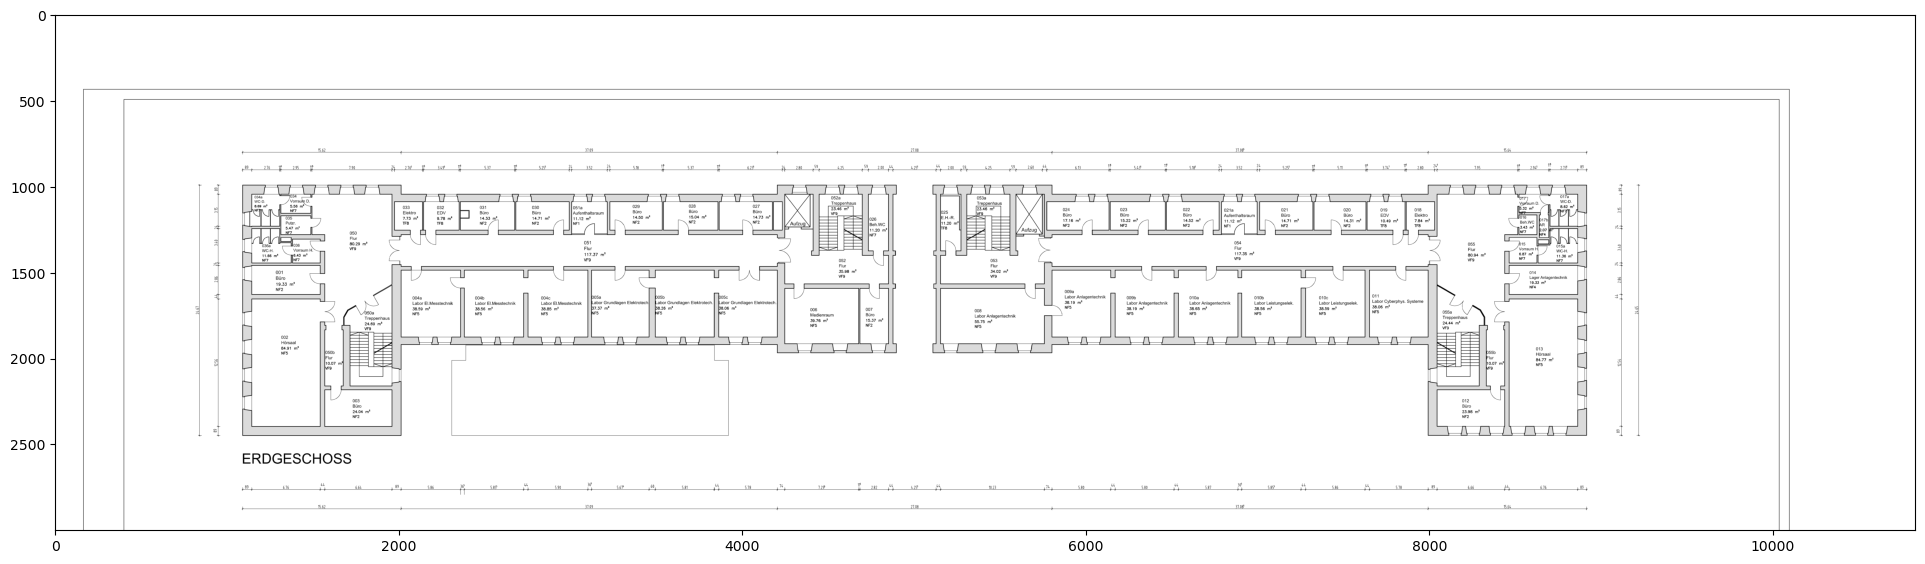

In [101]:
img = cv2.imread("../data/floorplans/05101_OTH-AM_Geb.G_GR_UG-EG_M200_13-01-2020.png", cv2.IMREAD_GRAYSCALE)

plt.figure(figsize=(24,16))
plt.imshow(img[:3000,:], cmap='gray')

img_eg = img[:3000, :]

In [102]:
np.unique(img_eg, return_counts=True)

(array([  0,  54,  63, 109, 127, 164, 191, 219, 255], dtype=uint8),
 array([  545637,      926,    20396,    46068,   198817,      777,
           20923,  1053787, 30602669], dtype=int64))

### Mauerpixel extrahieren
Hintergrundpixel haben die Intensität 255. Mauerpixel werden durch die Pixel mit dem zweithöchsten Vorkommen (Intensität 219) repräsentiert. 

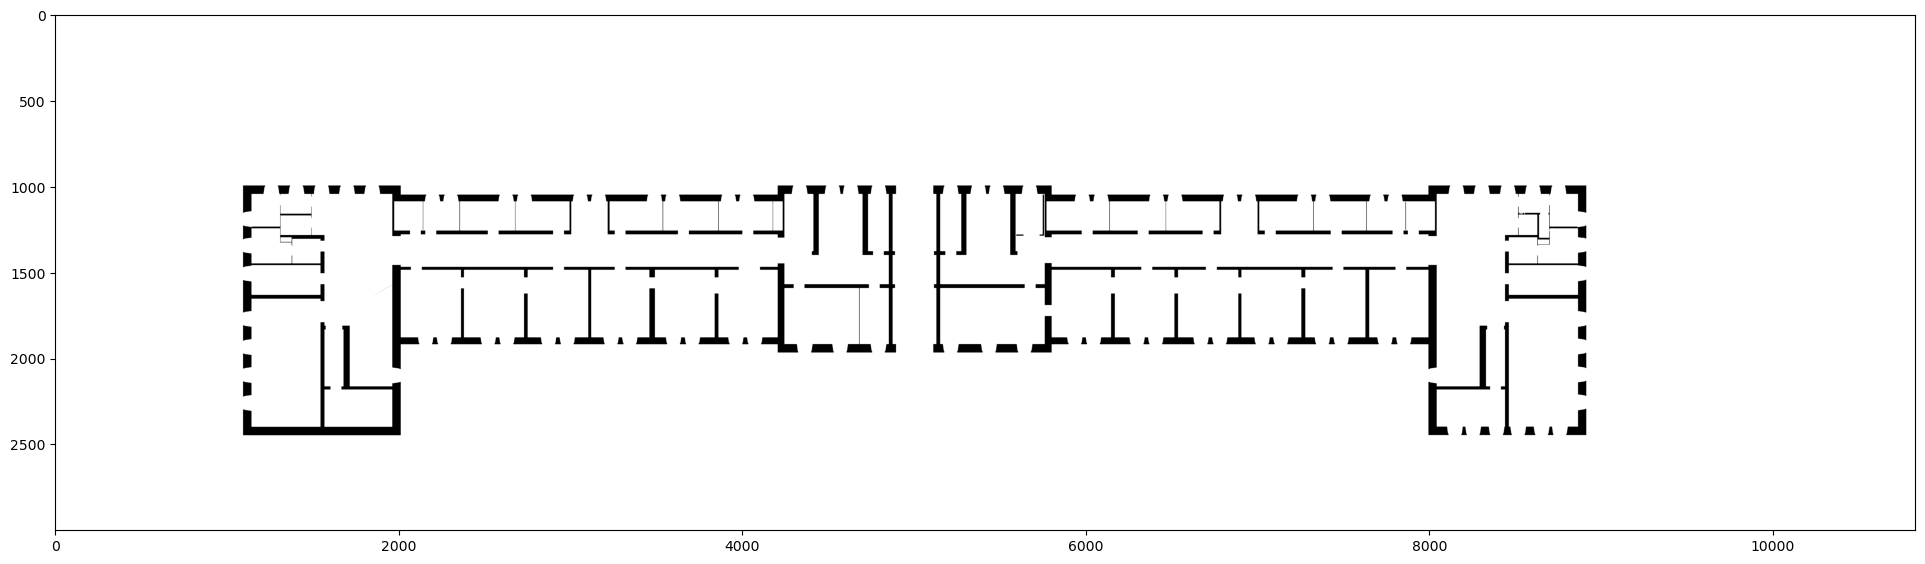

In [103]:
img_filtered = np.ones_like(img_eg)
img_filtered[img_eg == 219] = 0

plt.figure(figsize=(24,16))
plt.imshow(img_filtered, cmap='gray')

Aufgrund der Art der Extraktion der Mauerpixel liegt leichtes Rauschen vor. Dieses wird mit Opening entfernt.

In [104]:
occupancy_map = cv2.morphologyEx(
    img_filtered.astype(np.uint8),
    cv2.MORPH_OPEN,
    np.ones((3,3), np.uint8)
)

### Skalierung der Map
Das gesamte Gebäude hat eine Länge von $~132,5m$.

In [105]:
extent_m = 132.5

ys, xs = np.where(occupancy_map == 0)

xmin = xs.min()
xmax = xs.max()

extent_px = xmax-xmin
current_res = extent_m / extent_px

print(f"Die Ausdehnung des Gebäudes in Pixeln ist {extent_px}px.")
print(f"Das ergibt eine Auflösung von {current_res}px.")

scale_factor = current_res / RESOLUTION
grid_width = int(np.round(img_eg.shape[1] * scale_factor))
grid_height = int(np.round(img_eg.shape[0] * scale_factor))

grid_height

Die Ausdehnung des Gebäudes in Pixeln ist 7820px.
Das ergibt eine Auflösung von 0.01694373401534527px.


254

In [106]:
grid = cv2.resize(
    occupancy_map.astype(np.uint8),
    (grid_width, grid_height),
    interpolation=cv2.INTER_NEAREST
)

ys, xs = np.where(grid == 0)

xmin = xs.min()
xmax = xs.max()

extent_px = xmax-xmin
current_res = extent_m / extent_px

print(f"Länge nach Skalierung: {extent_px*current_res}")

Länge nach Skalierung: 132.5


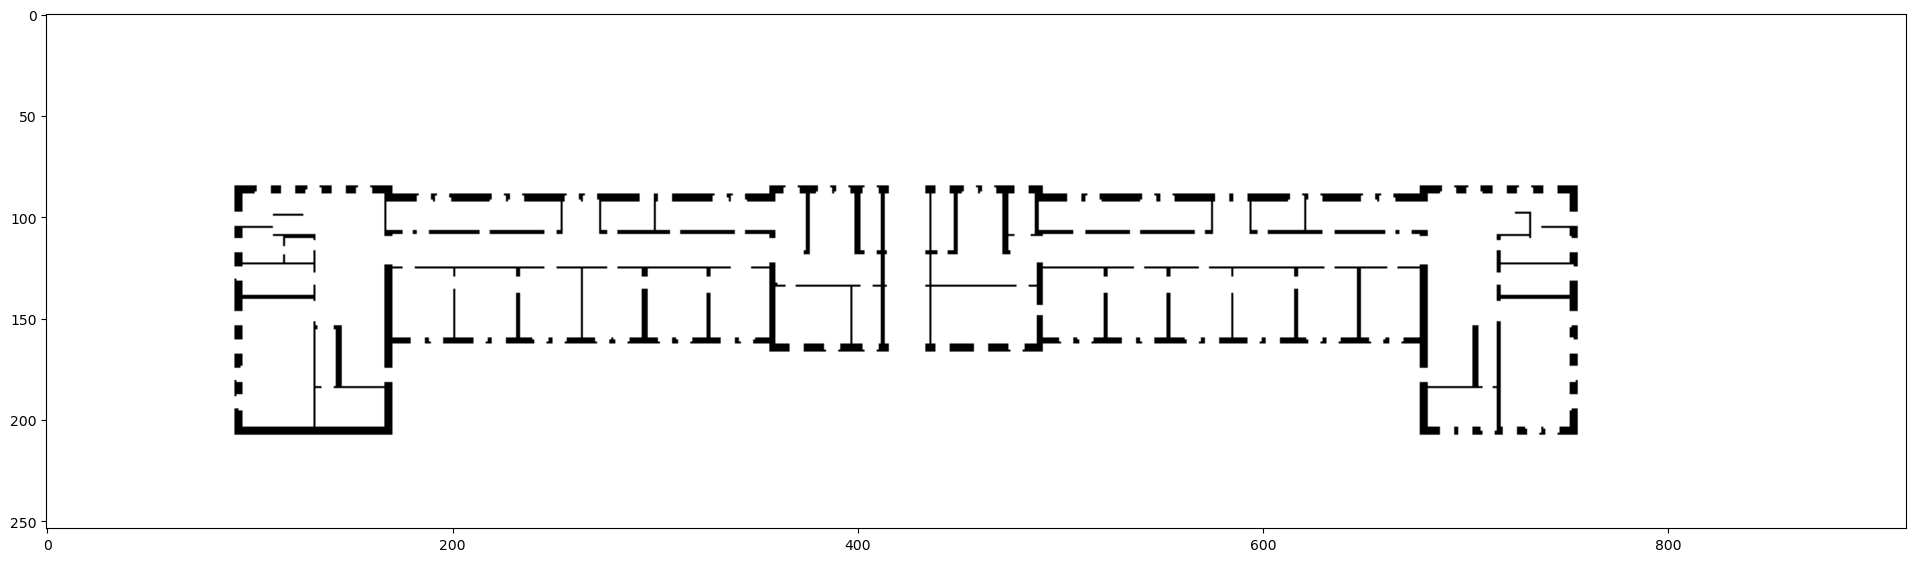

In [107]:
plt.figure(figsize=(24,16))
plt.imshow(grid, cmap='gray')

## Entfernen der Whitespaces

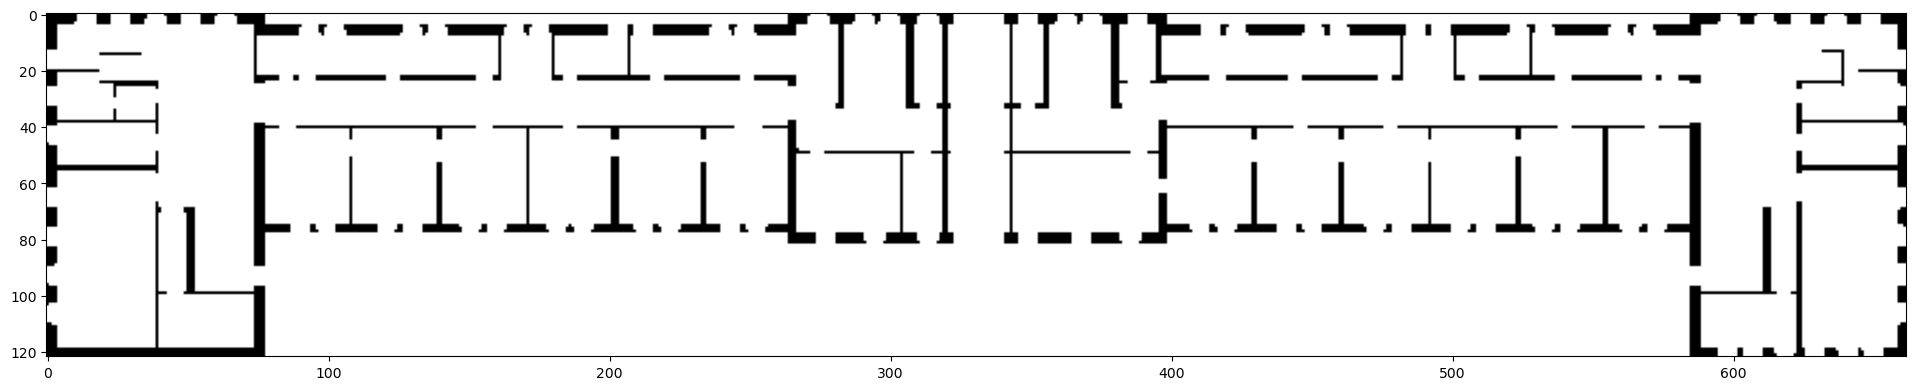

In [114]:
ys, xs = np.where(grid == 0)

xmin = xs.min()
xmax = xs.max()
ymin = ys.min()
ymax = ys.max()

grid_final = grid[ymin:ymax, xmin:xmax]

plt.figure(figsize=(24,16))
plt.imshow(grid_final, cmap='gray')